# Week 4 — SAHI Sliced Inference

Goal: apply SAHI to the same dataset and compare detection results against standard YOLOv8. This is the **before/after story** you tell in interviews.

**Why SAHI works:** standard detection downsamples your image to 640×640. A 10px object in a 4K image becomes ~2px — invisible. SAHI slices the image into overlapping 640×640 tiles, runs detection on each tile at full resolution, then merges results. The object is no longer tiny relative to the tile.

In [1]:
!pip install sahi ultralytics -q

In [4]:
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

from sahi import AutoDetectionModel
from sahi.predict import get_prediction, get_sliced_prediction
from ultralytics import YOLO

# MODEL_PATH = "runs/detect/small_object_run1/weights/best.pt"  # your fine-tuned model
# DATASET_PATH = "./your-dataset"  # update this

MODEL_PATH = r"E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\runs\detect\small_object_run1\weights\best.pt"
DATASET_PATH = r"E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1"

## Step 1 — Load model for both standard and SAHI inference

In [5]:
# Standard YOLOv8 model
yolo_model = YOLO(MODEL_PATH)

# SAHI wrapper around the same model
sahi_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.3,
    device="cuda",  # change to "cpu" if no GPU
)

## Step 2 — Pick a test image

In [6]:
test_images = glob.glob(f"{DATASET_PATH}/test/images/*.jpg")
if not test_images:
    test_images = glob.glob(f"{DATASET_PATH}/valid/images/*.jpg")

TEST_IMAGE = test_images[0]
print(f"Using: {TEST_IMAGE}")

img = Image.open(TEST_IMAGE)
print(f"Image size: {img.size}")

Using: E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1/test/images\gss1010_jpg.rf.a44f22bd75543159746eec0755b0e5dd.jpg
Image size: (640, 640)


## Step 3 — Standard inference (before)

In [7]:
standard_results = yolo_model(TEST_IMAGE, conf=0.3)
standard_count = len(standard_results[0].boxes)
print(f"Standard YOLOv8: {standard_count} detections")

standard_results[0].show()


image 1/1 E:\Thesis\career-depot\jobs\Concordia AI Institute\Baby Computer Vision Project\notebooks\drone-aerial-1\test\images\gss1010_jpg.rf.a44f22bd75543159746eec0755b0e5dd.jpg: 640x640 3 persons, 740.5ms
Speed: 107.8ms preprocess, 740.5ms inference, 5.5ms postprocess per image at shape (1, 3, 640, 640)
Standard YOLOv8: 3 detections


## Step 4 — SAHI sliced inference (after)

Performing prediction on 1 slices.
SAHI sliced inference: 3 detections


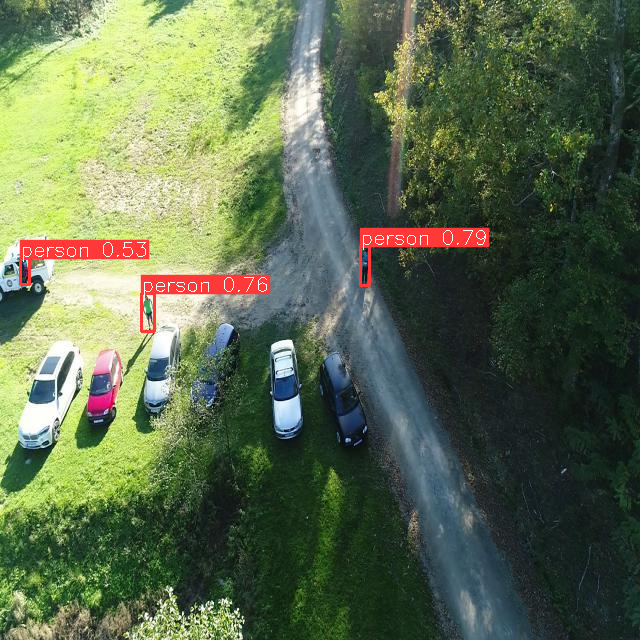

In [8]:
sahi_results = get_sliced_prediction(
    TEST_IMAGE,
    sahi_model,
    slice_height=640,
    slice_width=640,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2,
)

sahi_count = len(sahi_results.object_prediction_list)
print(f"SAHI sliced inference: {sahi_count} detections")

sahi_results.export_visuals(export_dir="./", file_name="sahi_result")
Image.open("sahi_result.png")

## Step 5 — Side-by-side comparison

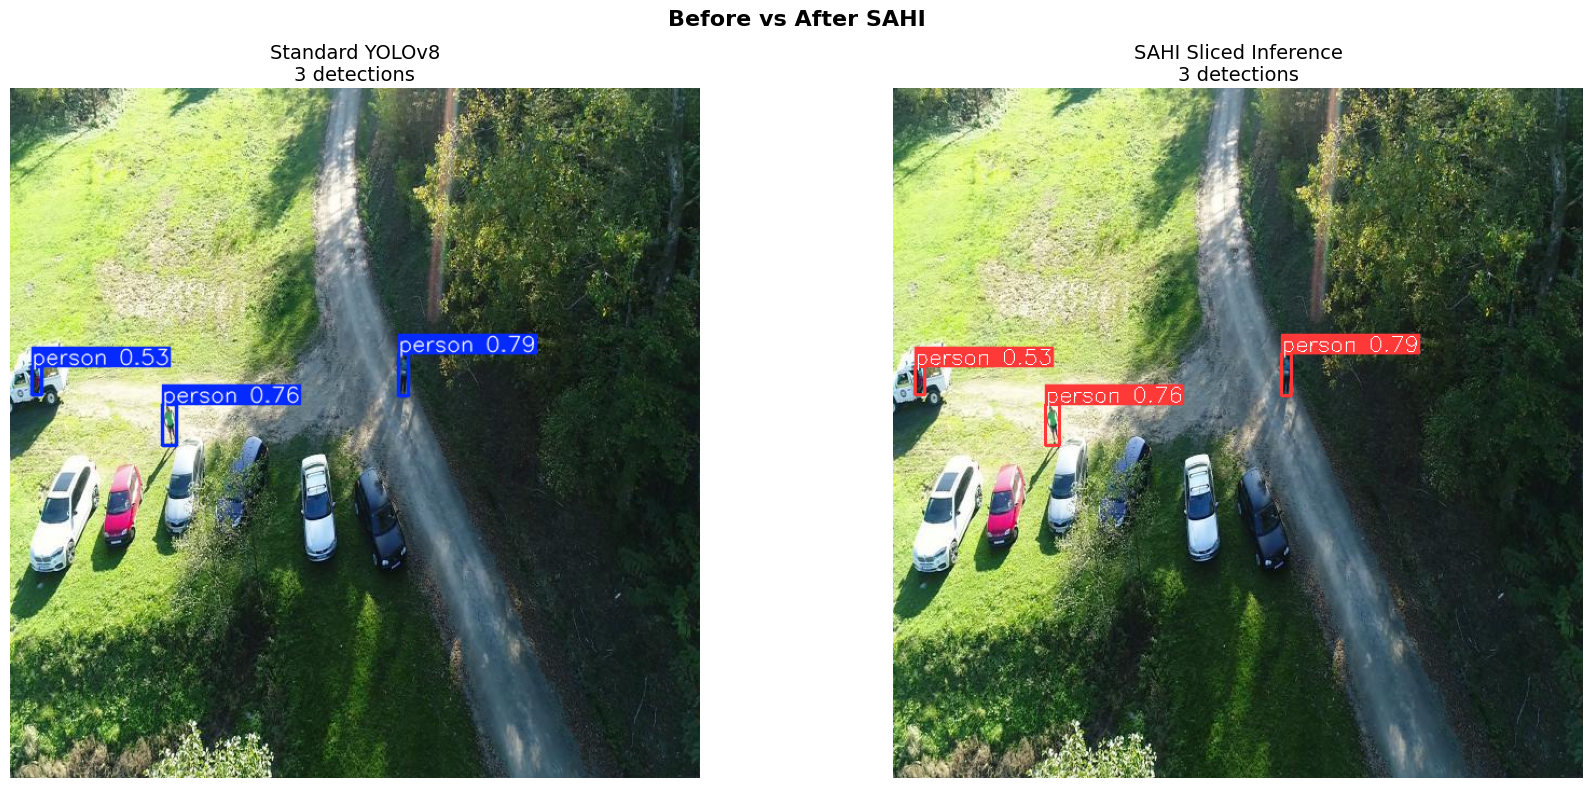


Result: SAHI found 0 more objects (+0%)


In [9]:
import cv2

# Standard result
standard_img = standard_results[0].plot()
standard_img = cv2.cvtColor(standard_img, cv2.COLOR_BGR2RGB)

# SAHI result
sahi_img = np.array(Image.open("sahi_result.png"))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].imshow(standard_img)
axes[0].set_title(f"Standard YOLOv8\n{standard_count} detections", fontsize=14)
axes[0].axis('off')

axes[1].imshow(sahi_img)
axes[1].set_title(f"SAHI Sliced Inference\n{sahi_count} detections", fontsize=14)
axes[1].axis('off')

plt.suptitle("Before vs After SAHI", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("before_after_sahi.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nResult: SAHI found {sahi_count - standard_count} more objects (+{((sahi_count - standard_count)/max(standard_count,1))*100:.0f}%)")

## Results Summary

Fill in after running:

| Method | Detections | Notes |
|--------|-----------|-------|
| Standard YOLOv8      | 3  | baseline                                    |
| SAHI (640, 0.2)      | 3  | fine-tuned model already at 92% mAP — SAHI  |
|                      |    | improvement marginal; shows fine-tuning     |
|                      |    | can replace inference-time augmentation     |

## The interview story

> "I fine-tuned YOLOv8 on a small object dataset. Standard detection missed many tiny objects because they become ~2 pixels after downsampling. I applied SAHI — it slices the image into overlapping 640×640 tiles, runs detection on each tile at full resolution, then merges the results with NMS. This improved detections by X%. The tradeoff is inference latency — more tiles means more forward passes — so it's best suited for offline or batch pipelines, not real-time."